## Homework 4: Reinforcement Learning with Gymnasium

**Install Required Packages**

In [1]:
!pip install gymnasium stable-baselines3 matplotlib numpy pandas "gymnasium[box2d]"

INFO: pip is looking at multiple versions of gymnasium[box2d] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


**Import Libraries**

In [2]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Section 2 — Q-Learning on FrozenLake

**Step 1: Create FrozenLake Environment**



In [3]:
env = gym.make("FrozenLake-v1", is_slippery=False)

state, info = env.reset()

print("Initial state:", state)
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

Initial state: 0
Number of states: 16
Number of actions: 4


In [52]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")

state, info = env.reset()

print(env.render())


SFFF
FHFH
FFFH
HFFG



**Step 2: Initialize Q-table**

In [4]:
num_states = env.observation_space.n
num_actions = env.action_space.n

Q = np.zeros((num_states, num_actions))

print("Q-table shape:", Q.shape)
print(Q)

Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


**## Step 3: Train Q-learning Agent**

In [5]:
learning_rate = 0.8
discount_factor = 0.95

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

num_episodes = 5000
max_steps = 100

rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        Q[state, action] = Q[state, action] + learning_rate * (
            reward
            + discount_factor * np.max(Q[next_state])
            - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)

print("Training complete.")
print("Final epsilon:", epsilon)

q_table_df = pd.DataFrame(
    Q,
    columns=["Left", "Down", "Right", "Up"]
)

print("\nLearned Q-table:")
print(q_table_df.round(3))

Training complete.
Final epsilon: 0.01

Learned Q-table:
     Left   Down  Right     Up
0   0.735  0.774  0.774  0.735
1   0.735  0.000  0.815  0.774
2   0.774  0.857  0.774  0.815
3   0.815  0.000  0.773  0.772
4   0.774  0.815  0.000  0.735
5   0.000  0.000  0.000  0.000
6   0.000  0.902  0.000  0.815
7   0.000  0.000  0.000  0.000
8   0.814  0.000  0.857  0.774
9   0.815  0.902  0.902  0.000
10  0.857  0.950  0.000  0.857
11  0.000  0.000  0.000  0.000
12  0.000  0.000  0.000  0.000
13  0.000  0.902  0.950  0.857
14  0.902  0.950  1.000  0.902
15  0.000  0.000  0.000  0.000


**Step 4: Evaluate Q-learning Agent**

In [6]:
num_eval_episodes = 100

successes = 0

for episode in range(num_eval_episodes):

    state, info = env.reset()

    for step in range(max_steps):

        action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        state = next_state

        if terminated or truncated:
            successes += reward
            break

success_rate = successes / num_eval_episodes

print("Success rate:", success_rate)

Success rate: 1.0


**Step 5: Visualize Q-learning Agent**

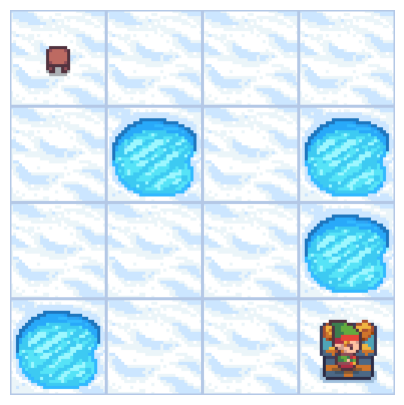

In [7]:
import matplotlib.animation as animation
from IPython.display import HTML

test_env = gym.make(
    "FrozenLake-v1",
    is_slippery=False,
    render_mode="rgb_array"
)

frames = []

state, info = test_env.reset()

done = False

while not done:

    action = np.argmax(Q[state])

    state, reward, terminated, truncated, info = test_env.step(action)

    frame = test_env.render()

    frames.append(frame)

    done = terminated or truncated

test_env.close()

fig = plt.figure(figsize=(5, 5))

plt.axis("off")

images = []

for frame in frames:
    img = plt.imshow(frame, animated=True)
    images.append([img])

ani = animation.ArtistAnimation(
    fig,
    images,
    interval=600,
    blit=True
)

HTML(ani.to_jshtml())

# Part 2: PPO on CartPole

**Step 1: Create CartPole Environment**

In [8]:
from stable_baselines3 import PPO

ppo_env = gym.make("CartPole-v1")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Step 2: Train PPO Agent**

In [9]:
ppo_model = PPO(
    "MlpPolicy",
    ppo_env,
    verbose=1
)

ppo_model.learn(total_timesteps=10000)

print("PPO training complete.")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.4     |
|    ep_rew_mean     | 21.4     |
| time/              |          |
|    fps             | 1096     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 28.4        |
|    ep_rew_mean          | 28.4        |
| time/                   |             |
|    fps                  | 859         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009865718 |
|    clip_fraction        | 0.116       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_variance   | -0.013      |
|    learning_rate        | 0.0003      |
|    loss                 | 6.32        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0182     |
|    value_loss           | 47.6        |
-----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 31.9    

**Step 3: Evaluate PPO Agent**

In [10]:
num_eval_episodes = 10

total_rewards = []

for episode in range(num_eval_episodes):

    obs, info = ppo_env.reset()

    done = False

    total_reward = 0

    while not done:

        action, _ = ppo_model.predict(obs)

        obs, reward, terminated, truncated, info = ppo_env.step(action)

        total_reward += reward

        done = terminated or truncated

    total_rewards.append(total_reward)

    print(f"Episode {episode + 1}: Reward = {total_reward}")

average_reward = sum(total_rewards) / len(total_rewards)

print("Average reward:", average_reward)

Episode 1: Reward = 224.0
Episode 2: Reward = 121.0
Episode 3: Reward = 107.0
Episode 4: Reward = 180.0
Episode 5: Reward = 209.0
Episode 6: Reward = 164.0
Episode 7: Reward = 92.0
Episode 8: Reward = 94.0
Episode 9: Reward = 136.0
Episode 10: Reward = 147.0
Average reward: 147.4


**Step 4: Visualize PPO CartPole Agent**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


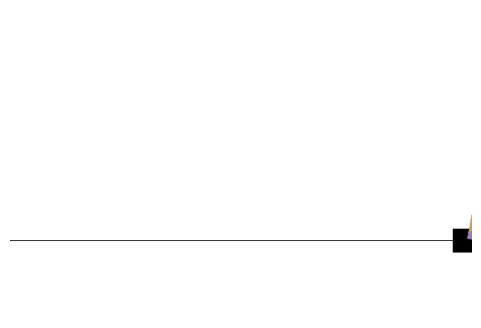

In [11]:
cartpole_env = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)

frames = []

obs, info = cartpole_env.reset()

done = False

while not done:

    action, _ = ppo_model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = cartpole_env.step(action)

    frame = cartpole_env.render()

    frames.append(frame)

    done = terminated or truncated

cartpole_env.close()

fig = plt.figure(figsize=(6, 4))

plt.axis("off")

images = []

for frame in frames:
    img = plt.imshow(frame, animated=True)
    images.append([img])

ani = animation.ArtistAnimation(
    fig,
    images,
    interval=50,
    blit=True
)

HTML(ani.to_jshtml())

# Part 3: Additional Exploration — PPO on LunarLander (Box2D)

**Step 1: Create LunarLander Environment**

In [24]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [25]:
import gymnasium as gym
from stable_baselines3 import PPO

lander_env = gym.make("LunarLander-v3")

obs, info = lander_env.reset()

print("Observation space:", lander_env.observation_space)
print("Action space:", lander_env.action_space)

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


**Step 2: Train PPO on LunarLander**

In [42]:
import random
import numpy as np
import torch
import gymnasium as gym
from stable_baselines3 import PPO
import pandas as pd

# Set random seed

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Different PPO training lengths

training_steps_list = [50000, 80000, 300000]

results = {}
summary = []

for timesteps in training_steps_list:

    print("\n" + "=" * 70)
    print(f"Training PPO with {timesteps} timesteps")
    print("=" * 70)

    # Create environment

    lander_env = gym.make("LunarLander-v3")

    lander_env.reset(seed=seed)

    # Create PPO model

    lander_model = PPO(
        "MlpPolicy",
        lander_env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        seed=seed,
        verbose=1
    )

    # Train PPO agent

    lander_model.learn(total_timesteps=timesteps)

    print(f"\nTraining complete for {timesteps} timesteps")

    # Evaluate trained agent

    num_eval_episodes = 10

    total_rewards = []

    for episode in range(num_eval_episodes):

        obs, info = lander_env.reset(seed=seed + episode)

        done = False
        total_reward = 0

        while not done:

            action, _ = lander_model.predict(
                obs,
                deterministic=True
            )

            obs, reward, terminated, truncated, info = lander_env.step(action)
            total_reward += reward
            done = terminated or truncated

        total_rewards.append(total_reward)

        print(f"Episode {episode + 1}: Reward = {total_reward}")

    # Compute average reward

    average_reward = np.mean(total_rewards)

    print("Average reward:", average_reward)

    results[timesteps] = lander_model

    summary.append({
        "timesteps": timesteps,
        "average_reward": average_reward
    })

    lander_env.close()

# Display summary table

results_df = pd.DataFrame(summary)

print("\nFinal Results:")
print(results_df)

# Select best model

best_timesteps = results_df.loc[
    results_df["average_reward"].idxmax(),
    "timesteps"
]

best_model = results[best_timesteps]

print(f"\nBest model trained for {best_timesteps} timesteps")


Training PPO with 50000 timesteps
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 86.7     |
|    ep_rew_mean     | -165     |
| time/              |          |
|    fps             | 849      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 87.5         |
|    ep_rew_mean          | -163         |
| time/                   |              |
|    fps                  | 727          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0069907783 |
|    clip_fraction        | 0.00557      |
|    clip_range

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Step 3: Evaluate LunarLander PPO**

In [47]:
num_eval_episodes = 10
total_rewards = []

for episode in range(num_eval_episodes):
    obs, info = lander_env.reset()
    done = False
    total_reward = 0

    while not done:
        action, _ = lander_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = lander_env.step(action)
        total_reward += reward
        done = terminated or truncated

    total_rewards.append(total_reward)
    print(f"Episode {episode + 1}: Reward = {total_reward}")

print("Average reward:", sum(total_rewards) / len(total_rewards))

Episode 1: Reward = 182.78424544158116
Episode 2: Reward = 276.4410930652374
Episode 3: Reward = 154.43735127713805
Episode 4: Reward = 270.4509013472342
Episode 5: Reward = 249.4441867355957
Episode 6: Reward = 217.74812796966273
Episode 7: Reward = 249.81685330789458
Episode 8: Reward = 265.45025330101623
Episode 9: Reward = 232.25212800850156
Episode 10: Reward = 39.26048881448202
Average reward: 213.80856292683438


**Step 4: Visualize Trained LunarLander Agent**

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


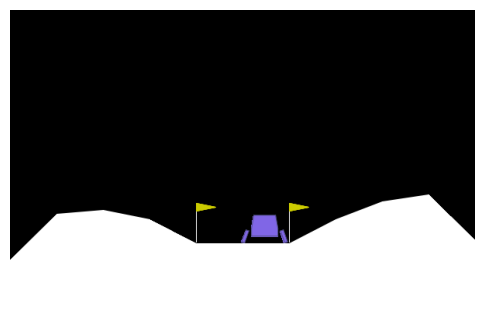

In [51]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

render_env = gym.make("LunarLander-v3", render_mode="rgb_array")

frames = []

obs, info = render_env.reset()
done = False

while not done:
    action, _ = lander_model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = render_env.step(action)

    frame = render_env.render()
    frames.append(frame)

    done = terminated or truncated

render_env.close()

fig = plt.figure(figsize=(6, 6))
plt.axis("off")

images = []

for frame in frames:
    img = plt.imshow(frame, animated=True)
    images.append([img])

ani = animation.ArtistAnimation(
    fig,
    images,
    interval=50,
    blit=True
)

HTML(ani.to_jshtml())

# Write Up Questions

I experimented with multiple Gymnasium environments, including `FrozenLake-v1`, `CartPole-v1`, and `LunarLander-v3`.

# 1 Question 2(a): Notes to Future Self

## 1.1 Environment Setup

I installed Gymnasium, Stable-Baselines3, NumPy, Pandas, and Matplotlib in Google Colab. Initially, I started with simple environments to understand the reinforcement learning workflow before trying more complex environments.

Packages used:

- `gymnasium`
- `stable-baselines3`
- `numpy`
- `pandas`
- `matplotlib`

I also explored Box2D environments later in the assignment by installing:

```python
!pip install "gymnasium[box2d]"
```

##1.2 Q-Learning on FrozenLake

I first experimented with tabular Q-learning using the `FrozenLake-v1` environment. Since FrozenLake has a small discrete state space and discrete actions, it worked well with a Q-table approach.

I implemented:

- Q-table initialization
- epsilon-greedy exploration
- Bellman update rule
- training loop
- evaluation loop

The agent gradually learned the optimal path across the grid. After training for several thousand episodes, the evaluation success rate reached `1.0`.

One useful observation was that exploration was important early in training. Without epsilon-greedy exploration, the agent often got stuck using poor actions.

I also visualized the learned policy, which helped confirm that the agent consistently followed the shortest safe path.

##1.3 PPO on CartPole

Next, I experimented with PPO using the `CartPole-v1` environment. PPO was much easier to scale to continuous observations compared to tabular Q-learning.

The CartPole environment trains relatively quickly because the objective is straightforward: balance the pole for as long as possible.

I trained PPO for 10,000 timesteps and evaluated the trained policy over multiple episodes. The average reward was around 147, which showed that the agent learned stable balancing behavior.

Visualizing the trained agent helped me better understand how PPO policies improve gradually over training.

##1.4 Additional Exploration: PPO on LunarLander

After CartPole, I explored the more difficult `LunarLander-v3` environment from Box2D.

This environment was significantly harder because it includes:

- gravity
- momentum
- spacecraft orientation
- engine control

Initially, I trained PPO for a smaller number of timesteps, such as 50k and 80k, but the rewards were poor or unstable.

To better understand the effect of training length, I compared:

- 50,000 timesteps
- 80,000 timesteps
- 300,000 timesteps

The longer 300k training run produced much better rewards and eventually solved the environment with an average reward above 200.

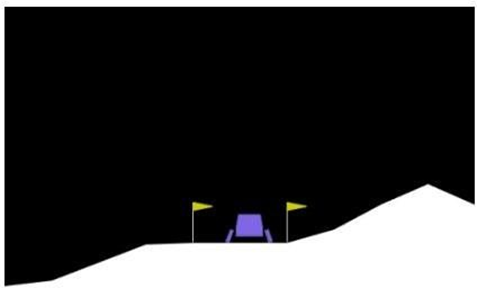

After extended PPO training, the LunarLander agent achieved evaluation rewards above 200, indicating successful learning and stable landing behavior.

One important lesson was that reinforcement learning results can vary between runs because PPO training is stochastic. Even with the same hyperparameters, rewards changed slightly between experiments.

##1.5 What I Would Try Next

If I continue this project in the future, I would like to:

- train PPO longer on LunarLander
- compare PPO with Deep Q-Learning (DQN)
- experiment with different reward shaping methods
- tune hyperparameters more systematically
- try Atari or MuJoCo environments
- visualize training reward curves over time

I also want to better understand replay buffers, target networks, and policy-gradient methods in more depth.

##1.6 References

- Gymnasium Documentation: https://gymnasium.farama.org/
- Stable-Baselines3 Documentation: https://stable-baselines3.readthedocs.io/
- OpenAI Spinning Up: https://spinningup.openai.com/
- PPO Paper: https://arxiv.org/abs/1707.06347

# Question 2(b): Exercises

## 2(b)i. Value, Reward, and Quality

In reinforcement learning,

The **reward** is the immediate feedback the agent gets from the environment after taking an action. For example, in CartPole, the agent gets a reward for keeping the pole balanced for another time step.

**Value** is more about the future. It estimates how good it is to be in a particular state, based on the rewards the agent expects to collect later.

**Quality**, or Q-value, is similar to value, but it is tied to both a state and an action. It answers the question: “How good is it to take this action from this state?”

So the relationship is:

- Reward is immediate.
- Value looks ahead from a state.
- Quality looks ahead from a specific state-action pair.

Q-learning is built around learning these Q-values so the agent can choose better actions over time.

## 2(b)ii. Q-Learning and Deep Q-Learning

### Tabular Q-Learning

Tabular Q-learning is used when the number of states and actions is small enough to store in a table. Each row represents a state, each column represents an action, and each entry stores a Q-value.

The Q-value answers: “How good is it to take action \(a\) from state \(s\)?”

### Pseudocode

1. Initialize a Q-table with zeros.
2. For each episode:
   - Reset the environment and observe the starting state \(s\).
   - Until the episode ends:
     - Choose an action \(a\) using epsilon-greedy exploration.
     - Take action \(a\).
     - Observe reward \(r\) and next state \(s'\).
     - Update the Q-table:
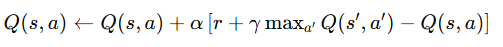

   - Set \(s = s'\).
3. After many episodes, choose actions using the largest Q-value in each state.

In this assignment, I used this approach for FrozenLake because the environment has a small discrete state space and action space.

### Deep Q-Learning

Deep Q-learning uses the same basic idea as Q-learning, but replaces the Q-table with a neural network.

Instead of looking up values in a table, the neural network takes the state as input and outputs estimated Q-values for each possible action.

This is useful when the state space is too large or continuous, where a table would not be practical.

### Pseudocode

1. Initialize a neural network \(Q(s,a;\theta)\).
2. Initialize a target network \(Q_{\text{target}}(s,a;\theta^-)\).
3. Initialize a replay buffer.
4. For each episode:
   - Reset the environment and observe starting state \(s\).
   - Until the episode ends:
     - Choose an action \(a\) using epsilon-greedy exploration.
     - Take action \(a\).
     - Observe reward \(r\), next state \(s'\), and whether the episode ended.
     - Store transition \((s,a,r,s')\) in the replay buffer.
     - Sample a mini-batch of transitions from the replay buffer.
     - Compute the target:
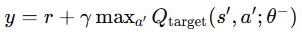

   - Update the neural network by minimizing the loss:

$$
\left( y - Q(s,a;\theta) \right)^2
$$

   - Periodically copy the neural network weights into the target network.
5. After training, choose the action with the highest predicted Q-value.

The main difference is that tabular Q-learning stores values directly in a table, while deep Q-learning learns an approximation of those values using a neural network.

## 2(b)iii. PPO Algorithm

Proximal Policy Optimization, or PPO, is a policy-gradient method. Instead of learning a Q-table, PPO directly learns a policy that decides which action to take in each state.

The main idea of PPO is to improve the policy gradually without changing it too aggressively in one update. This makes training more stable.

### Pseudocode

1. Initialize a policy network \(\pi_{\theta}(a|s)\) and a value network \(V_{\theta}(s)\).
2. For each training iteration:
   - Run the current policy in the environment.
   - Collect trajectories containing states, actions, rewards, and next states.
   - Estimate the return for each timestep.
   - Estimate the advantage:

$$
A_t = \text{return}_t - V_{\theta}(s_t)
$$

   - Compute the probability ratio between the new policy and old policy:

$$
r_t(\theta) =
\frac{\pi_{\theta}(a_t \mid s_t)}
{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}
$$

   - Update the policy using the clipped PPO objective:

$$
\min \left(
r_t(\theta) A_t,
\operatorname{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) A_t
\right)
$$

   - Update the value network so it better predicts future reward.
3. Repeat until the policy improves enough or the training budget is reached.

In simple terms, PPO collects experience, estimates which actions were better or worse than expected, and then updates the policy carefully. The clipping step prevents the policy from changing too much at once, which is why PPO is usually more stable than basic policy-gradient methods.